In [1]:
import pandas as pd
import os
print(os.getcwd())

import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

C:\Users\zhan5\OneDrive\Desktop\Quant\MetaLearner\Notebooks


In [2]:
from MetaLearner.Data.early_processing import (
    filter_for_date,
    drop_columns_with_na,
    create_column_of_days_after_2024,
    create_week_number_column,
)



In [3]:
from MetaLearner.Data.create_price_series import create_price_series_csv

price_data = create_price_series_csv()

price_data = filter_for_date(price_data)
price_data = drop_columns_with_na(price_data)
price_data = create_column_of_days_after_2024(price_data)
price_data = create_week_number_column(price_data )
price_data.shape


Saved 2094 rows to C:\Users\zhan5\OneDrive\Desktop\Quant\MetaLearner\Datafiles\all_daily_adjusted_close.csv
Dropped columns []
Their missing values are, Series([], dtype: int64)


(1591, 49)

In [4]:
from MetaLearner.Data.create_regime_data import (
    get_gold_n_intest_data,
    get_cpi_data,
    get_VIX_data,
    pull_sp500_data,
    create_regime_data
)

In [5]:
gold_n_treasury_prices  = get_gold_n_intest_data()
cpi_df, interest_rate_df = get_cpi_data()
vix = get_VIX_data()
sp500_df = pull_sp500_data()

[*********************100%***********************]  2 of 2 completed


Price             Close                High                 Low         \
Ticker             GC=F   ^TNX         GC=F   ^TNX         GC=F   ^TNX   
Date                                                                     
2008-01-02   857.000000  3.901   857.799988  4.052   846.400024  3.892   
2008-01-03   866.400024  3.901   865.500000  3.958   856.299988  3.892   
2008-01-04   863.099976  3.854   865.500000  3.990   860.200012  3.809   
2008-01-07   859.599976  3.839   860.900024  3.903   857.400024  3.833   
2008-01-08   878.000000  3.840   879.400024  3.897   861.599976  3.837   
...                 ...    ...          ...    ...          ...    ...   
2026-04-27  4675.399902  4.336  4711.100098  4.350  4675.399902  4.310   
2026-04-28  4591.500000  4.354  4680.899902  4.378  4591.500000  4.351   
2026-04-29  4545.200195  4.418  4601.600098  4.432  4515.700195  4.362   
2026-04-30  4614.700195  4.390  4636.700195  4.410  4561.899902  4.382   
2026-05-01  4644.500000  4.378  4673.0

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Date',     ''),
            ('Close', '^VIX')],
           names=['Price', 'Ticker'])


[*********************100%***********************]  1 of 1 completed


In [6]:
# MetaLearner.Data.create_regime_data
regime_data = create_regime_data(
        sp500_df,
    interest_rate_df,
    cpi_df,
    gold_n_treasury_prices ,
    vix,
) 


Number of missing data points: Date                         0
sp500_Close                  0
sp500_Volume                 0
prev_month_interest_rate     0
prev_month_cpi              20
gold_close                   3
treasury_yield_close         1
VIX_Close                    0
dtype: int64
Forward filled


In [7]:
from MetaLearner.Data.examine_data_quality import download_daily_data, find_tickers,  check_data_quality

In [8]:
existing_tickers = find_tickers(price_data)
check_data_quality(price_data, existing_tickers)

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Index(['Date', 'CHRW_Close_tested'], dtype='str') Index(['Date', 'CHRW_Close_testing'], dtype='str')
0.9999999999998487
Index(['Date', 'FAST_Close_tested'], dtype='str') Index(['Date', 'FAST_Close_testing'], dtype='str')
0.999999999999868
Index(['Date', 'EHC_Close_tested'], dtype='str') Index(['Date', 'EHC_Close_testing'], dtype='str')
0.9999999999999137
Index(['Date', 'TGT_Close_tested'], dtype='str') Index(['Date', 'TGT_Close_testing'], dtype='str')
0.9999999999997639
Index(['Date', 'XLE_Close_tested'], dtype='str') Index(['Date', 'XLE_Close_testing'], dtype='str')
0.9999999999999046
Index(['Date', 'LW_Close_tested'], dtype='str') Index(['Date', 'LW_Close_testing'], dtype='str')
0.9999999999996999
Index(['Date', 'XLRE_Close_tested'], dtype='str') Index(['Date', 'XLRE_Close_testing'], dtype='str')
0.9999999999988861
Index(['Date', 'XLY_Close_tested'], dtype='str') Index(['Date', 'XLY_Close_testing'], dtype='str')
0.9999999999996706
Index(['Date', 'XLB_Close_tested'], dtype='str') Inde

In [9]:
price_data = filter_for_date(price_data, '2020-01-01')

In [10]:

from MetaLearner.Data.create_sector_and_industries import extract_price_and_volume_columns_and_tickers,  fetch_sector_industry, create_ticker_sector_industry_df


In [11]:
price_columns, volume_columns, tickers = extract_price_and_volume_columns_and_tickers(price_data)

In [12]:



sector_industry_df = create_ticker_sector_industry_df(tickers, fetch_sector_industry)

CHRW
EHC
DHI
LW
FAST
THG
ATO
TGT
WCC
AMG
XLK
XLF
XLI
XLV
XLY
XLP
XLU
XLRE
XLC
XLE
XLB
SPY


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SP500"}}}


sp500


In [13]:
mapping = sector_industry_df.copy()

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

In [15]:
price_data = price_data.set_index('Date') 

In [16]:
sector_industry_df 

,Ticker,Sector,Industry
0,CHRW,Industrials,Integrated Freight & Logistics
1,EHC,Healthcare,Medical Care Facilities
2,DHI,Consumer Cyclical,Residential Construction
3,LW,Consumer Defensive,Packaged Foods
4,FAST,Industrials,Industrial Distribution
5,THG,Financial Services,Insurance - Property & Casualty
6,ATO,Utilities,Utilities - Regulated Gas
7,TGT,Consumer Defensive,Discount Stores
8,WCC,Industrials,Industrial Distribution
9,AMG,Financial Services,Asset Management


In [17]:
price_series = price_data[ 'LW_Close']

In [19]:
from MetaLearner.Data.MomentumFeatures import create_lag_return, create_fut_return,  create_auto_correlation_forecast, fill_missing_correlation_coefficients, popolute_momentum_data, create_compressed_forecast_features

In [20]:
# fill_missing_correlation_coefficients(p, 'MMM', 30, 21)   
# available_AR_values_per_stock

In [21]:
from MetaLearner.Data.MeanReversionFeatures import create_residual_mean_reversion_features, fill_missing_mean_reversion_features, create_mean_reversion_variants,  concat_mean_reversion_dataframes, build_other_mean_reversion_features

In [22]:
from  MetaLearner.Data.BuildBasicFeatures import build_features, build_base_features_for_one_ticker, add_sector, append_features, create_ranking_df, create_rolling_1m_volume_data, append_volume_data

In [23]:
import gc
gc.collect()

available_mean_reversion_features_per_ticker = {}

In [24]:
sector_to_etf = {
    "Industrials": "XLI",
    "Healthcare": "XLV",
    "Technology": "XLK",
    "Utilities": "XLU",
    "Financial Services": "XLF",
    "Basic Materials": "XLB",
    "Real Estate": "XLRE",
    "Communication Services": "XLC",
    "Consumer Defensive": "XLP",
    "Consumer Cyclical": "XLY",
    "Energy": "XLE",
    np.nan: "SPY"   # fallback
}

In [25]:
from pathlib import Path
import sys

# Ensure project root is importable regardless current notebook cwd.
project_root = Path.cwd()
if project_root.name.lower() == "notebooks" and project_root.parent.name.lower() == "metalearner":
    project_root = project_root.parent.parent
elif project_root.name.lower() == "metalearner":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from MetaLearner.Data.SaveLoadDictionaryDB import (
    load_dictionary_database,
    save_dictionary_database,
)

default_directory = str(project_root / "MetaLearner" / "Datafiles")
base_mr_file_name = "mean_reversion_base_feature_database.pkl"
vannila_mr_file_name = "vannila_mean_reversion_feature_database.pkl"

print(f"PKL databases will be stored in: {default_directory}")


PKL databases will be stored in: C:\Users\zhan5\OneDrive\Desktop\Quant\MetaLearner\Datafiles


In [26]:
windows = [126, 252, 504]

available_mean_reversion_features_per_ticker = load_dictionary_database(default_directory, base_mr_file_name )
vannila_mean_reversion_features = load_dictionary_database(default_directory, vannila_mr_file_name)

# available_mean_reversion_features_per_ticker = {}
# vannila_mean_reversion_features  = {}

temp_tickers = ['CHRW',
 'EHC',
 'DHI',
 'LW',
 'FAST',
 'THG',
 'ATO',
 # 'TGT',
 # 'WCC',
 # 'AMG'
               ]

selected_tickers = temp_tickers


for ticker in selected_tickers:
    sector = sector_industry_df[sector_industry_df['Ticker'] == ticker]['Sector'].iloc[0]
    etf_name = sector_to_etf[sector]
    
    stock_column = f'{ticker}_Close'
    etf_column = f'{etf_name}_Close'
    sp500_column = 'sp500_Close'
          
    p = price_data[stock_column]
    etf_p = price_data[etf_column]
    sp500_p = price_data[sp500_column]

    vannila_mean_reversion_df = build_other_mean_reversion_features(
                                                                    p, 
                                         etf_p , 
                                         sp500_p 
                                         )
    vannila_mean_reversion_features[ticker] = vannila_mean_reversion_df
    # print(vannila_mean_reversion_df.shape)
    
    for window in windows:
        fill_missing_mean_reversion_features(available_mean_reversion_features_per_ticker,
                                             p,
                                            etf_p,
                                         sp500_p,
                                         ticker, 'price', window)
        
        fill_missing_mean_reversion_features(available_mean_reversion_features_per_ticker,
                                             p,
                                            etf_p,
                                         sp500_p,
                                         ticker, 'return', window)

save_dictionary_database(available_mean_reversion_features_per_ticker, default_directory, base_mr_file_name)
save_dictionary_database(vannila_mean_reversion_features , default_directory, vannila_mr_file_name)

price_mean_reversion_variants_dataframes = {}
return_mean_reversion_variants_dataframes = {}

for ticker in selected_tickers:
    price_mean_reversion_variants_df = create_mean_reversion_variants(available_mean_reversion_features_per_ticker, 
                                                                      ticker, windows, is_price_series = True)
    return_mean_reversion_variants_df = create_mean_reversion_variants(available_mean_reversion_features_per_ticker, 
                                                                       ticker, windows, is_price_series = False)
    price_mean_reversion_variants_dataframes[ticker] = price_mean_reversion_variants_df
    return_mean_reversion_variants_dataframes[ticker] =  return_mean_reversion_variants_df

Database found: C:\Users\zhan5\OneDrive\Desktop\Quant\MetaLearner\Datafiles\mean_reversion_base_feature_database.pkl
Database found: C:\Users\zhan5\OneDrive\Desktop\Quant\MetaLearner\Datafiles\vannila_mean_reversion_feature_database.pkl
2026-05-01 00:00:00 mean_reversion_sector_price_d126 data created
2026-05-01 00:00:00 mean_reversion_econ_price_d126 data created
2026-05-01 00:00:00 mean_reversion_sector_return_d126 data created
2026-05-01 00:00:00 mean_reversion_econ_return_d126 data created
2026-05-01 00:00:00 mean_reversion_sector_price_d252 data created
2026-05-01 00:00:00 mean_reversion_econ_price_d252 data created
2026-05-01 00:00:00 mean_reversion_sector_return_d252 data created
2026-05-01 00:00:00 mean_reversion_econ_return_d252 data created
2026-05-01 00:00:00 mean_reversion_sector_price_d504 data created
2026-05-01 00:00:00 mean_reversion_econ_price_d504 data created
2026-05-01 00:00:00 mean_reversion_sector_return_d504 data created
2026-05-01 00:00:00 mean_reversion_econ_re

In [27]:
print('i')

i


In [28]:
price_mean_reversion_variants_dataframes = {}
return_mean_reversion_variants_dataframes = {}

for ticker in selected_tickers:
    print(ticker)
    price_mean_reversion_variants_df = create_mean_reversion_variants(available_mean_reversion_features_per_ticker, 
                                                                      ticker, windows, is_price_series = True)
    return_mean_reversion_variants_df = create_mean_reversion_variants(available_mean_reversion_features_per_ticker, 
                                                                       ticker, windows, is_price_series = False)
    price_mean_reversion_variants_dataframes[ticker] = price_mean_reversion_variants_df
    return_mean_reversion_variants_dataframes[ticker] =  return_mean_reversion_variants_df

CHRW
EHC
DHI
LW
FAST
THG
ATO


In [29]:
selected_tickers = ['CHRW', 'EHC', 'DHI', 'LW', 'FAST', 'THG', 'ATO']

In [30]:
    
global_mean_reversion_df = concat_mean_reversion_dataframes([vannila_mean_reversion_features,
    price_mean_reversion_variants_dataframes,
    return_mean_reversion_variants_dataframes], selected_tickers).reset_index().rename(columns = {'index':'Date'})



In [31]:

            
LOOKBACKS = [1, 5, 10, 25, 60, 120, 250]

mom_file_name = "momentum_feature_database.pkl"

# available_AR_values_per_stock = load_dictionary_database(default_directory, mom_file_name )
available_AR_values_per_stock = {}
popolute_momentum_data(price_data, available_AR_values_per_stock, 
                       LOOKBACKS,
                      selected_tickers)

save_dictionary_database(available_AR_values_per_stock , default_directory, mom_file_name)

CHRW
1
5
10
25
60
120
250
EHC
1
5
10
25
60
120
250
DHI
1
5
10
25
60
120
250
LW
1
5
10
25
60
120
250
FAST
1
5
10
25
60
120
250
THG
1
5
10
25
60
120
250
ATO
1
5
10
25
60
120
250


'C:\\Users\\zhan5\\OneDrive\\Desktop\\Quant\\MetaLearner\\Datafiles\\momentum_feature_database.pkl'

In [32]:
all_momentum_features = []

ticker_dfs = []

for ticker in selected_tickers:
    print(ticker)
    ticker_series = pd.DataFrame()
    ticker_data = available_AR_values_per_stock[ticker]
    for combo in ticker_data:
        print(combo)
        lag_time = combo.split('_')[1]
        return_and_p_value = pd.Series(ticker_data[combo])
        return_series = return_and_p_value.apply(lambda x: x[0])
        p_value_series = return_and_p_value.apply(lambda x: x[1])
        ticker_series[f'{combo}_forecast_return'] = return_series
        ticker_series[f'{combo}_p_value'] = p_value_series
        ticker_series[f'forecast_s_times_1_minus_pval_{lag_time}'] = return_series*(1-p_value_series)
        ticker_series['Ticker'] = ticker
        # ticker_dfs.append(ticker_series)
    # ticker_momentum_df = pd.concat(ticker_dfs, axis = 1).reset_index().rename(columns = {'index':'Date'})
    # print(ticker_momentum_df.shape)
    ticker_momentum_df = ticker_series
    all_momentum_features.append(ticker_momentum_df)
momentum_df = pd.concat(all_momentum_features).reset_index().rename(columns = {'index':'Date'})

CHRW
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
EHC
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
DHI
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
LW
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
FAST
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
THG
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21
ATO
lag_1_hold_21
lag_5_hold_21
lag_10_hold_21
lag_25_hold_21
lag_60_hold_21
lag_120_hold_21
lag_250_hold_21


Creating a mean reversion dataframe for MMM to see if the features computed is identical with the features computed by

In [33]:
temp = pd.concat([vannila_mean_reversion_features['LW'], price_mean_reversion_variants_dataframes['LW'], return_mean_reversion_variants_dataframes['LW']], axis = 1)

In [34]:
temp = global_mean_reversion_df[global_mean_reversion_df ['Ticker'] == 'LW'].reset_index()
temp

,index,Date,Stock_price,ETF_price,SP500_price,Stock_return,Sector_return,Econ_return,vr_5d,vr_20d,...,econ_r_z_times_1_minus_p_value_504,econ_r_resid_std_times_z_times_1_minus_p_value_504,econ_r_res_mom_12_1_504,econ_r_res_rev_5d_504,econ_r_res_rsi_14_504,econ_r_res_streak_504,econ_r_macd_line_504,econ_r_macd_signal_504,econ_r_macd_hist_504,Ticker
0,4773,2020-01-02,75.763382,52.989933,3257.850098,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LW
1,4774,2020-01-03,84.295670,52.905121,3234.850098,0.106715,-0.001602,-0.007085,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LW
2,4775,2020-01-06,81.718872,53.015381,3246.280029,-0.031046,0.002082,0.003527,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LW
3,4776,2020-01-07,82.178375,52.608288,3237.179932,0.005607,-0.007708,-0.002807,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LW
4,4777,2020-01-08,82.223434,52.803349,3253.050049,0.000548,0.003701,0.004890,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,6359,2026-04-27,43.320000,82.339996,7173.910156,-0.022822,-0.010751,0.001232,1.022084,0.592175,...,-0.722860,-0.022065,-0.349140,0.058501,44.587557,0.0,-0.002213,0.000475,-0.002688,LW
1587,6360,2026-04-28,43.080002,83.080002,7138.799805,-0.005556,0.008947,-0.004906,1.341178,0.553473,...,-0.019063,-0.000582,-0.335106,0.038148,48.531882,0.0,-0.001909,-0.000002,-0.001907,LW
1588,6361,2026-04-29,43.029999,82.919998,7135.950195,-0.001161,-0.001928,-0.000399,0.695135,0.543483,...,0.025749,0.000786,-0.338508,0.036793,50.412064,1.0,-0.001539,-0.000309,-0.001230,LW
1589,6362,2026-04-30,43.549999,84.309998,7209.009766,0.012012,0.016624,0.010186,0.519758,1.164629,...,0.224220,0.006845,-0.291211,0.010197,48.488440,2.0,-0.000749,-0.000397,-0.000352,LW


In [35]:
from MetaLearner.OldFunctions.MeanReversionFunctions import build_original_mean_reversion_features

original_features_built = build_original_mean_reversion_features(price_data, 'LW_Close', 'XLP_Close', 'sp500_Close').reset_index()

126  period computed
2020-07-01 00:00:00 2020-01-02 00:00:00
2020-07-02 00:00:00 2020-01-03 00:00:00
2020-07-06 00:00:00 2020-01-06 00:00:00
2020-07-07 00:00:00 2020-01-07 00:00:00
2020-07-08 00:00:00 2020-01-08 00:00:00
2020-07-09 00:00:00 2020-01-09 00:00:00
2020-07-10 00:00:00 2020-01-10 00:00:00
2020-07-13 00:00:00 2020-01-13 00:00:00
2020-07-14 00:00:00 2020-01-14 00:00:00
2020-07-15 00:00:00 2020-01-15 00:00:00
2020-07-16 00:00:00 2020-01-16 00:00:00
2020-07-17 00:00:00 2020-01-17 00:00:00
2020-07-20 00:00:00 2020-01-21 00:00:00
2020-07-21 00:00:00 2020-01-22 00:00:00
2020-07-22 00:00:00 2020-01-23 00:00:00
2020-07-23 00:00:00 2020-01-24 00:00:00
2020-07-24 00:00:00 2020-01-27 00:00:00
2020-07-27 00:00:00 2020-01-28 00:00:00
2020-07-28 00:00:00 2020-01-29 00:00:00
2020-07-29 00:00:00 2020-01-30 00:00:00
2020-07-30 00:00:00 2020-01-31 00:00:00
2020-07-31 00:00:00 2020-02-03 00:00:00
2020-08-03 00:00:00 2020-02-04 00:00:00
2020-08-04 00:00:00 2020-02-05 00:00:00
2020-08-05 00:00:00

In [36]:
common_features = original_features_built.columns.intersection(temp.columns)
missing_features = original_features_built.columns.difference(temp.columns)
missing_features

Index([], dtype='str')

In [37]:
for colum in temp.columns:
    print(colum)

index
Date
Stock_price
ETF_price
SP500_price
Stock_return
Sector_return
Econ_return
vr_5d
vr_20d
vr_60d
vr_120d
sector_tracking_error_d1
econ_tracking_error_d1
sector_p_beta_d126
sector_p_resid_std_d126
sector_p_resid_z_d126
sector_p_resid_total_deviation_per_price_d126
sector_p_resid_adf_p_d126
sector_p_z_times_1_minus_p_value_126
sector_p_resid_std_times_z_times_1_minus_p_value_126
sector_p_res_mom_06_1_126
sector_p_res_rev_5d_126
sector_p_res_rsi_14_126
sector_p_res_streak_126
sector_p_macd_line_126
sector_p_macd_signal_126
sector_p_macd_hist_126
sector_p_beta_d252
sector_p_resid_std_d252
sector_p_resid_z_d252
sector_p_resid_total_deviation_per_price_d252
sector_p_resid_adf_p_d252
sector_p_z_times_1_minus_p_value_252
sector_p_resid_std_times_z_times_1_minus_p_value_252
sector_p_res_mom_12_1_252
sector_p_res_rev_5d_252
sector_p_res_rsi_14_252
sector_p_res_streak_252
sector_p_macd_line_252
sector_p_macd_signal_252
sector_p_macd_hist_252
sector_p_beta_d504
sector_p_resid_std_d504
secto

In [38]:
original_features_built.columns

Index(['Date', 'Stock_price', 'ETF_price', 'SP500_price', 'Stock_return',
       'Sector_return', 'Econ_return', 'vr_5d', 'vr_20d', 'vr_60d', 'vr_120d',
       'sector_tracking_error_d1', 'econ_tracking_error_d1',
       'sector_p_beta_d126', 'sector_p_resid_std_d126',
       'sector_p_resid_z_d126',
       'sector_p_resid_total_deviation_per_price_d126',
       'sector_p_resid_adf_p_d126', 'sector_p_z_times_1_minus_p_value_126',
       'sector_p_resid_std_times_z_times_1_minus_p_value_126',
       'sector_p_res_mom_06_1_126', 'sector_p_res_rev_5d_126',
       'sector_p_res_rsi_14_126', 'sector_p_res_streak_126',
       'sector_p_macd_line_126', 'sector_p_macd_signal_126',
       'sector_p_macd_hist_126'],
      dtype='str')

In [39]:
print('Existing mean reversion features are', temp.columns), print('Sample of old mean reversion feature',original_features_built.columns)

Existing mean reversion features are Index(['index', 'Date', 'Stock_price', 'ETF_price', 'SP500_price',
       'Stock_return', 'Sector_return', 'Econ_return', 'vr_5d', 'vr_20d',
       ...
       'econ_r_z_times_1_minus_p_value_504',
       'econ_r_resid_std_times_z_times_1_minus_p_value_504',
       'econ_r_res_mom_12_1_504', 'econ_r_res_rev_5d_504',
       'econ_r_res_rsi_14_504', 'econ_r_res_streak_504',
       'econ_r_macd_line_504', 'econ_r_macd_signal_504',
       'econ_r_macd_hist_504', 'Ticker'],
      dtype='str', length=183)
Sample of old mean reversion feature Index(['Date', 'Stock_price', 'ETF_price', 'SP500_price', 'Stock_return',
       'Sector_return', 'Econ_return', 'vr_5d', 'vr_20d', 'vr_60d', 'vr_120d',
       'sector_tracking_error_d1', 'econ_tracking_error_d1',
       'sector_p_beta_d126', 'sector_p_resid_std_d126',
       'sector_p_resid_z_d126',
       'sector_p_resid_total_deviation_per_price_d126',
       'sector_p_resid_adf_p_d126', 'sector_p_z_times_1_minus_p_

(None, None)

In [40]:
print('Common features are:', common_features)
if original_features_built.columns.isin(temp.columns).all():
    print('new mean reversion features include all sample features')
else:
    print('Misisng features:', missing_features)

Common features are: Index(['Date', 'Stock_price', 'ETF_price', 'SP500_price', 'Stock_return',
       'Sector_return', 'Econ_return', 'vr_5d', 'vr_20d', 'vr_60d', 'vr_120d',
       'sector_tracking_error_d1', 'econ_tracking_error_d1',
       'sector_p_beta_d126', 'sector_p_resid_std_d126',
       'sector_p_resid_z_d126',
       'sector_p_resid_total_deviation_per_price_d126',
       'sector_p_resid_adf_p_d126', 'sector_p_z_times_1_minus_p_value_126',
       'sector_p_resid_std_times_z_times_1_minus_p_value_126',
       'sector_p_res_mom_06_1_126', 'sector_p_res_rev_5d_126',
       'sector_p_res_rsi_14_126', 'sector_p_res_streak_126',
       'sector_p_macd_line_126', 'sector_p_macd_signal_126',
       'sector_p_macd_hist_126'],
      dtype='str')
new mean reversion features include all sample features


In [41]:
price_data.to_csv('Experimental_data.csv')

In [42]:
from sklearn.metrics import r2_score

bad_features = []

for feature in common_features:
    common_indices = temp[feature].dropna().index.intersection(original_features_built[feature].dropna().index)
    print(feature)
    print((temp.loc[common_indices, feature] == original_features_built.loc[common_indices, feature]).all(),
          (temp.loc[common_indices, feature]== original_features_built.loc[common_indices, feature]).sum(),
          temp[feature].dropna().shape[0])
    data_similarity = r2_score( original_features_built.loc[common_indices, feature], temp.loc[common_indices, feature])
    print(data_similarity )
    # print(temp.loc[common_indices, feature].head(), original_features_built.loc[common_indices, feature].head())
    if data_similarity < 0.995:
        bad_features.append(feature)
    print('------------------')

Date
True 1591 1591
1.0
------------------
Stock_price
True 1591 1591
1.0
------------------
ETF_price
True 1591 1591
1.0
------------------
SP500_price
True 1591 1591
1.0
------------------
Stock_return
True 1590 1590
1.0
------------------
Sector_return
True 1590 1590
1.0
------------------
Econ_return
True 1590 1590
1.0
------------------
vr_5d
True 1582 1582
1.0
------------------
vr_20d
True 1552 1552
1.0
------------------
vr_60d
True 1472 1472
1.0
------------------
vr_120d
True 1352 1352
1.0
------------------
sector_tracking_error_d1
True 1087 1087
1.0
------------------
econ_tracking_error_d1
True 1087 1087
1.0
------------------
sector_p_beta_d126
False 3 1465
0.9999999999990521
------------------
sector_p_resid_std_d126
False 3 1465
0.9999999999996445
------------------
sector_p_resid_z_d126
False 3 1465
0.9999999999909888
------------------
sector_p_resid_total_deviation_per_price_d126
False 3 1465
0.9999999999928012
------------------
sector_p_resid_adf_p_d126
False 3 146

In [43]:

if len(bad_features) == 0:
    print('No bad features')
else:
    print('Bad features are:')
    for feature in bad_features:
        print(feature)
        temp_series = temp[feature].dropna()
        or_series = original_features_built[feature].dropna()
        
        # print(temp_series)
        # print(or_series)
    
        print('----------------------------')

No bad features


In [44]:
import numpy as np
from functools import reduce

# -------- 1) Build regime features once --------
# regime_data has a 'Date' column + multiple regime columns (rates, gold, etc.)
reg = regime_data.copy()
reg['Date'] = pd.to_datetime(reg['Date'])
reg = reg.sort_values('Date').set_index('Date')

reg_feats_parts = []
reg_last_parts  = []

for col in reg.columns:  # every regime series
    f, last = build_features(reg[col].astype(float))
    # drop the regime 'y' (your target is stock return, not regime-return)
    f = f.drop(columns=['y']).add_prefix(f"reg_{col}__").reset_index().rename(columns={'index': 'Date'})
    last = last.add_prefix(f"reg_{col}__").reset_index().rename(columns={'index': 'Date'})
    reg_feats_parts.append(f)
    reg_last_parts.append(last)

# Merge all regime feature blocks on Date
def _merge_on_date(a, b): 
    return a.merge(b, on='Date', how='outer')

regime_feats = reduce(_merge_on_date, reg_feats_parts) if reg_feats_parts else pd.DataFrame(columns=['Date'])
regime_last  = reduce(_merge_on_date, reg_last_parts)  if reg_last_parts  else pd.DataFrame(columns=['Date'])

C:\Users\zhan5\miniconda3\envs\jupyter_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\zhan5\miniconda3\envs\jupyter_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [45]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def build_base_features_for_one_ticker(ticker, price_data, mapping, sector_to_etf):

    price_column  = f'{ticker}_Close'
    volume_column = f'{ticker}_Volume'

    # --- Price features ---
    feats_p, last_p = build_features(price_data[price_column].astype(float))
    feats_p = feats_p.reset_index().rename(columns={'index': 'Date'})
    last_p  = last_p.reset_index().rename(columns={'index': 'Date'})

    # --- Volume features ---
    feats_v, last_v = build_features(price_data[volume_column].astype(float))
    feats_v = feats_v.drop(columns=['y']).add_prefix('vol_').reset_index().rename(columns={'index': 'Date'})
    last_v  = last_v.add_prefix('vol_').reset_index().rename(columns={'index': 'Date'})

    # --- Merge stock price + volume features ---
    feats_i = feats_p.merge(feats_v, on='Date', how='left')
    feats_i['Ticker'] = ticker
    last_i = last_p.merge(last_v, on='Date', how='left')
    last_i['Ticker'] = ticker

    # --- Sector ETF features ---
    sector = mapping.loc[mapping['Ticker'] == ticker, 'Sector']
    sector = sector.iloc[0] if not sector.empty else np.nan
    etf_ticker = sector_to_etf.get(sector, "SPY")

    etf_price_col = f"{etf_ticker}_Close"
    etf_vol_col   = f"{etf_ticker}_Volume"

    if etf_price_col in price_data.columns and etf_vol_col in price_data.columns:
        etf_p, etf_last_p = build_features(price_data[etf_price_col].astype(float))
        etf_p = etf_p.drop(columns=['y']).add_prefix("etf_").reset_index().rename(columns={"index": "Date"})
        etf_last_p = etf_last_p.add_prefix("etf_").reset_index().rename(columns={"index": "Date"})

        etf_v, etf_last_v = build_features(price_data[etf_vol_col].astype(float))
        etf_v = etf_v.drop(columns=['y']).add_prefix("etf_vol_").reset_index().rename(columns={"index": "Date"})
        etf_last_v = etf_last_v.add_prefix("etf_vol_").reset_index().rename(columns={"index": "Date"})

        feats_i = feats_i.merge(etf_p, on="Date", how="left").merge(etf_v, on="Date", how="left")
        last_i  = last_i.merge(etf_last_p, on="Date", how="left").merge(etf_last_v, on="Date", how="left")


    # --- Mean reversion features ---

    return feats_i, last_i
    
mmm_df = build_base_features_for_one_ticker('LW', price_data, mapping, sector_to_etf)
# mmm_df

In [46]:
all_basic_features = []

for ticker in selected_tickers:
    base_features = build_base_features_for_one_ticker(ticker, price_data, mapping, sector_to_etf)
    all_basic_features.append(base_features)

In [47]:
base_features_train = pd.concat([features[0] for features in all_basic_features])
base_features_deploy = pd.concat([features[1] for features in all_basic_features])

In [48]:
# base_features_train.merge(momentum_df)
# momentum_df


base_features_train  = add_sector(base_features_train, mapping)
base_features_deploy  = add_sector(base_features_deploy, mapping)
momentum_df  = add_sector(momentum_df, mapping)
global_mean_reversion_df   = add_sector(global_mean_reversion_df , mapping)

In [49]:
momentum_df = create_compressed_forecast_features(momentum_df )

In [50]:
momentum_df 

,Date,lag_1_hold_21_forecast_return,lag_1_hold_21_p_value,forecast_s_times_1_minus_pval_1,Ticker,lag_5_hold_21_forecast_return,lag_5_hold_21_p_value,forecast_s_times_1_minus_pval_5,lag_10_hold_21_forecast_return,lag_10_hold_21_p_value,...,Sector_Healthcare*average_forecasted_returns_of_momentums,Sector_Healthcare*short_forecasted_returns_of_momentums,Sector_Healthcare*long_forecasted_returns_of_momentums,Sector_Industrials*average_forecasted_returns_of_momentums,Sector_Industrials*short_forecasted_returns_of_momentums,Sector_Industrials*long_forecasted_returns_of_momentums,Sector_Utilities*average_forecasted_returns_of_momentums,Sector_Utilities*short_forecasted_returns_of_momentums,Sector_Utilities*long_forecasted_returns_of_momentums,Sector
0,2020-01-02,NaN,NaN,NaN,CHRW,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Industrials
1,2020-01-03,NaN,NaN,NaN,CHRW,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Industrials
2,2020-01-06,NaN,NaN,NaN,CHRW,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Industrials
3,2020-01-07,NaN,NaN,NaN,CHRW,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Industrials
4,2020-01-08,-0.002387,0.745323,-0.000608,CHRW,NaN,NaN,NaN,NaN,NaN,...,-0.0,NaN,NaN,-0.002387,NaN,NaN,-0.000000,NaN,NaN,Industrials
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11132,2026-04-27,-0.000056,0.014876,-0.000056,ATO,0.000395,0.032866,0.000382,0.001472,0.106487,...,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.006948,-0.002597,-0.019096,Utilities
11133,2026-04-28,-0.000500,0.014876,-0.000493,ATO,-0.002770,0.032866,-0.002679,0.000710,0.106487,...,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.007908,-0.003744,-0.019941,Utilities
11134,2026-04-29,0.000466,0.014876,0.000460,ATO,-0.002129,0.032866,-0.002059,0.000383,0.106487,...,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.006820,-0.003194,-0.017716,Utilities
11135,2026-04-30,-0.001413,0.014876,-0.001392,ATO,-0.001394,0.032866,-0.001348,-0.001380,0.106487,...,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.008846,-0.004424,-0.021408,Utilities


In [51]:
ranking_df = create_ranking_df(price_data)

In [52]:
def append_features(data_to_append_on:pd.DataFrame,
              features:pd.DataFrame):
    if features.columns.isin(data_to_append_on).all():
        return data_to_append_on
    else:
        existing_columns = [i for i in features.columns if i in data_to_append_on.columns and i not in ['Ticker', 'Date']]
        data_to_append_on = data_to_append_on.drop(existing_columns, axis = 1) 
    df = data_to_append_on.merge(features, on = ['Ticker', 'Date'], how = 'left')
    return df

print(base_features_train.shape)
base_features_train = append_features(base_features_train ,
              momentum_df)
base_features_deploy = append_features(base_features_deploy ,
              momentum_df)

print(base_features_train.shape)
base_features_train = append_features(base_features_train ,
              global_mean_reversion_df )
base_features_deploy = append_features(base_features_deploy ,
              global_mean_reversion_df )

print(base_features_train.shape)
base_features_train = append_features(base_features_train ,
              ranking_df )
base_features_deploy = append_features(base_features_deploy ,
              ranking_df )
print(base_features_train.shape)

(11137, 133)
(11137, 175)
(11137, 355)
(11137, 358)


In [53]:

base_features_train.dropna(axis = 1, how = 'all', inplace = True) 
print(base_features_train .shape)
base_features_deploy.dropna(axis = 0, how = 'all', inplace = True) 
print(base_features_deploy.shape)

(11137, 346)
(7, 357)


In [54]:

    
rolling_1m_dollar_volume_df = create_rolling_1m_volume_data(price_data)
base_features_train = append_volume_data(base_features_train, rolling_1m_dollar_volume_df)
base_features_deploy = append_volume_data(base_features_deploy, rolling_1m_dollar_volume_df)

In [55]:
base_features_train['forecast_s_times_1_minus_pval_25*1_month_dollar_volume'] = base_features_train['rolling_1m_dollar_volume']*base_features_train['forecast_s_times_1_minus_pval_25']
base_features_train['forecast_s_times_1_minus_pval_60*1_month_dollar_volume'] = base_features_train['rolling_1m_dollar_volume']*base_features_train['forecast_s_times_1_minus_pval_60']
base_features_train['forecast_s_times_1_minus_pval_120*1_month_dollar_volume'] = base_features_train['rolling_1m_dollar_volume']*base_features_train['forecast_s_times_1_minus_pval_120']
base_features_train['forecast_s_times_1_minus_pval_250*1_month_dollar_volume'] = base_features_train['rolling_1m_dollar_volume']*base_features_train['forecast_s_times_1_minus_pval_250']

base_features_deploy['forecast_s_times_1_minus_pval_25*1_month_dollar_volume'] =base_features_deploy ['rolling_1m_dollar_volume']*base_features_deploy ['forecast_s_times_1_minus_pval_25']
base_features_deploy ['forecast_s_times_1_minus_pval_60*1_month_dollar_volume'] = base_features_deploy ['rolling_1m_dollar_volume']*base_features_deploy ['forecast_s_times_1_minus_pval_60']
base_features_deploy ['forecast_s_times_1_minus_pval_120*1_month_dollar_volume'] = base_features_deploy ['rolling_1m_dollar_volume']*base_features_deploy ['forecast_s_times_1_minus_pval_120']
base_features_deploy ['forecast_s_times_1_minus_pval_250*1_month_dollar_volume'] = base_features_deploy ['rolling_1m_dollar_volume']*base_features_deploy ['forecast_s_times_1_minus_pval_250']

In [56]:
base_features_train.to_csv('new_pipeline_train.csv')
base_features_deploy.to_csv('new_pipeline_deploy.csv')

In [58]:
from MetaLearner.StockSelection import SelectionConfig, run_rolling_backtest_selection, identify_stocks_for_deployment
from MetaLearner.Backtest import run_30_backtests, summarize_backtest_metrics, plot_equity_curves

# Unified training frame for stock-selection modeling
# (data_process_script already built 99% of this: we now run model/backtest/selection)
temp_feat_df = base_features_train.copy()
temp_feat_df['Date'] = pd.to_datetime(temp_feat_df['Date'])

selection_cfg = SelectionConfig(
    horizon_bd=21,
    model_type='elastic_net',
    train_data_density='soft',
    k_top=8,
    corr_thresh=0.9,
    nan_corr='reject',
    exclude_tickers=('sp500',),
)


In [59]:
# Canonical final aliases (ensures downstream cells use Backtest orchestration)
# Keep this as the cell to run after data processing is complete.
from MetaLearner.Backtest import run_selection_backtest

results_df = run_selection_backtest(
    df_all=temp_feat_df,
    price_df=price_data,
    config=selection_cfg,
    spacing_days=11,
    lookback_windows=8,
)
results_df['Num_stock'] = results_df['Returns'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Keep old variable name compatibility too
results_df_v2 = results_df.copy()
results_df[['TEST_DATE', 'Selected tickers (rows mode)', 'TopK mean realized return', 'Avg_predicted_return', 'Num_stock']].head()


,TEST_DATE,Selected tickers (rows mode),TopK mean realized return,Avg_predicted_return,Num_stock
0,2026-05-01,[],0.000000,0.000000,1
1,2026-04-16,[],0.000000,0.000000,1
2,2026-03-31,[],0.000000,0.000000,1
3,2026-03-16,[LW],0.079522,0.016134,1
4,2026-02-27,"[LW, CHRW, EHC, DHI]",-0.146438,0.045377,4


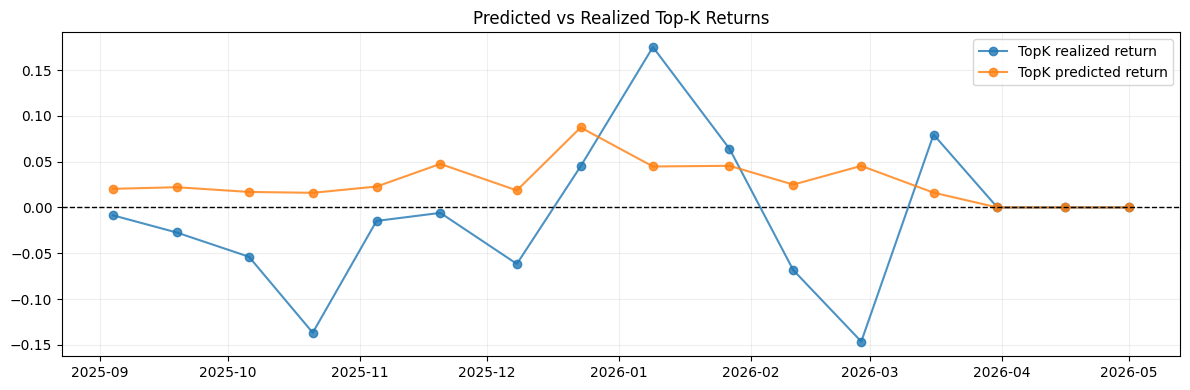

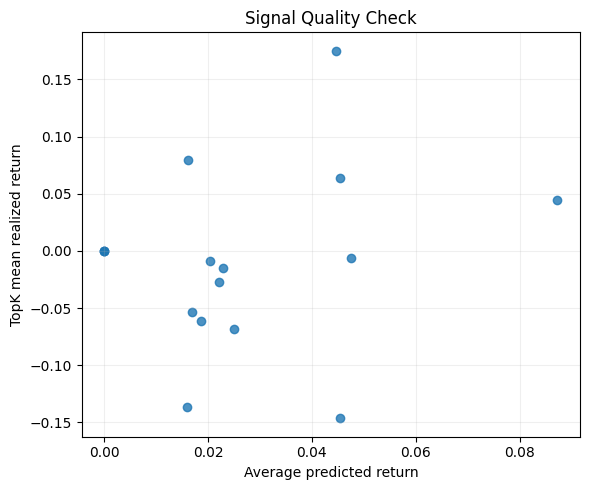

In [60]:
import matplotlib.pyplot as plt

# Quick strategy diagnostics
viz_df = results_df.copy()
viz_df['TEST_DATE'] = pd.to_datetime(viz_df['TEST_DATE'])

plt.figure(figsize=(12, 4))
plt.plot(viz_df['TEST_DATE'], viz_df['TopK mean realized return'], label='TopK realized return', marker='o', alpha=0.8)
plt.plot(viz_df['TEST_DATE'], viz_df['Avg_predicted_return'], label='TopK predicted return', marker='o', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.grid(alpha=0.2)
plt.title('Predicted vs Realized Top-K Returns')
plt.tight_layout()

plt.figure(figsize=(6, 5))
plt.scatter(viz_df['Avg_predicted_return'], viz_df['TopK mean realized return'], alpha=0.8)
plt.xlabel('Average predicted return')
plt.ylabel('TopK mean realized return')
plt.title('Signal Quality Check')
plt.grid(alpha=0.2)
plt.tight_layout()


In [61]:
# Portfolio-level backtest on selected tickers
bt_source = results_df[(results_df['Avg_predicted_return'] > 0.0) & (results_df['Num_stock'] >= 3)].copy()

metrics_df, equities = run_30_backtests(price_data, bt_source, hold_days=21)
summary = summarize_backtest_metrics(metrics_df)
print(summary)
metrics_df


{'worst_drawdown': -0.16648660682048522, 'average_return': -0.10143873779858213, 'average_sharp': -2.2328973692744314}


,backtest_id,start_trade_day,final_return,max_drawdown,risk_adjusted_return,risk
0,1,2025-11-05,-0.135337,-0.166487,-1.564780,0.011512
1,2,2025-11-20,-0.076831,-0.166487,-0.923132,0.011379
2,3,2025-12-08,-0.122994,-0.166487,-1.686405,0.011812
3,4,2026-01-27,-0.077894,-0.166487,-1.573277,0.011704
4,5,2026-02-11,-0.059846,-0.064448,-2.203876,0.007857
5,6,2026-02-27,-0.135730,-0.135730,-5.445914,0.009517


In [62]:
bt_source

,TEST_DATE,Selected tickers (rows mode),Returns,Predicted_returns,TopK mean realized return,Avg_predicted_return,Num_stock,HORIZON_BD,Train end (exclusive),Train samples,...,Train R^2,Train RMSE,Train MAE,Train Directional Acc,Test R^2,Test RMSE,Test MAE,Test Directional Acc,Test Correlation,Picked rows count
4,2026-02-27,"[LW, CHRW, EHC, DHI]","[-0.16279967322473543, -0.13118915761900343, -...","[0.08060874779226808, 0.04480882549189527, 0.0...",-0.146438,0.045377,4,21.0,2026-01-29,511.0,...,0.449604,0.067681,0.050181,0.701375,-3.975487,0.148507,0.117085,0.285714,-0.705402,4.0
5,2026-02-11,"[LW, CHRW, THG, ATO]","[-0.21427579382227688, -0.14417847608369733, 0...","[0.0511087543651961, 0.029420498488855786, 0.0...",-0.068403,0.024936,4,21.0,2026-01-13,511.0,...,0.449604,0.067681,0.050181,0.701375,-1.071823,0.137107,0.109371,0.714286,-0.195194,4.0
6,2026-01-27,"[LW, CHRW, EHC, THG]","[0.06020597207980857, 0.02002755802458556, 0.1...","[0.07951085343260186, 0.07795169911887946, 0.0...",0.064063,0.045454,4,21.0,2025-12-29,504.0,...,0.448754,0.067489,0.049793,0.689243,-3.778463,0.067484,0.060620,0.857143,-0.426745,4.0
9,2025-12-08,"[DHI, THG, FAST, CHRW, LW]","[-0.043784028371080384, -0.002119530199861314,...","[0.04477933219569549, 0.01514394796006892, 0.0...",-0.061675,0.018586,5,21.0,2025-11-07,497.0,...,0.455334,0.066304,0.049253,0.696970,-0.277893,0.152074,0.098021,0.285714,-0.097697,5.0
10,2025-11-20,"[CHRW, FAST, LW, ATO, THG, DHI]","[0.10882261139517835, 0.06429896716538007, -0....","[0.09640644443524865, 0.06560574809912449, 0.0...",-0.005941,0.047498,6,21.0,2025-10-22,490.0,...,0.459385,0.066451,0.049383,0.709016,-0.313289,0.131183,0.078718,0.571429,0.024740,6.0
11,2025-11-05,"[CHRW, EHC, LW]","[0.03035285387928631, -0.02458420096644419, -0...","[0.0438099545964922, 0.01495927221096809, 0.00...",-0.014739,0.022794,3,21.0,2025-10-07,483.0,...,0.458450,0.066532,0.049458,0.708940,-0.760893,0.055087,0.042727,0.428571,-0.250294,3.0


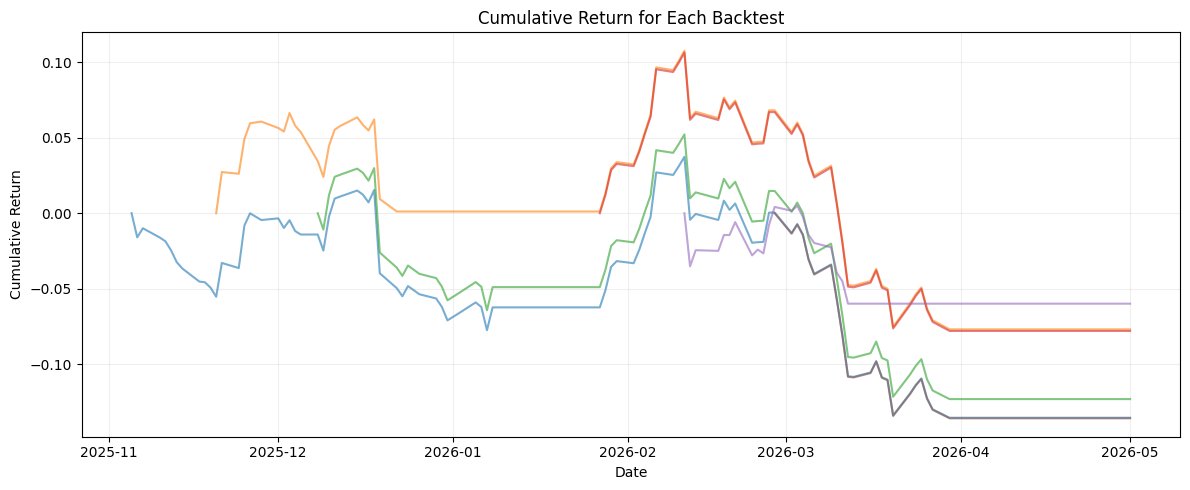

In [63]:
# Equity-curve visualization across rolling backtests
plot_equity_curves(equities, title='Cumulative Return for Each Backtest')

In [64]:
# Deployment stock selection from latest feature rows
# base_features_deploy already contains the latest scoring rows
deployment_results = identify_stocks_for_deployment(
    df_all=temp_feat_df,
    deploy_df=base_features_deploy,
    price_df=price_data,
    config=selection_cfg,
)

deployment_results

{'TEST_DATE': datetime.date(2026, 5, 1),
 'Selected tickers (rows mode)': [],
 'Top Predicted Returns': [],
 'Avg_predicted_return': 0.0}

In [65]:
# Gap conclusion from notebook comparison (kept in notebook for traceability)
required_buildout = {
    'Backtest submodule': [
        'run_30_backtests',
        'summarize_backtest_metrics',
        'plot_equity_curves',
    ],
    'StockSelection submodule': [
        'SelectionConfig',
        'select_topk_rows_with_corr_filter',
        'run_experiment_single_day',
        'run_rolling_backtest_selection',
        'identify_stocks_for_deployment',
    ],
}
required_buildout

{'Backtest submodule': ['run_30_backtests',
  'summarize_backtest_metrics',
  'plot_equity_curves'],
 'StockSelection submodule': ['SelectionConfig',
  'select_topk_rows_with_corr_filter',
  'run_experiment_single_day',
  'run_rolling_backtest_selection',
  'identify_stocks_for_deployment']}

In [66]:
# Comparison conclusion: what still had to be implemented in MetaLearner
# after data_process_script completed the 99% data-processing layer.
required_buildout = {
    'new_python_files': [
        'MetaLearner/StockSelection/selection_engine.py',
        'MetaLearner/StockSelection/__init__.py',
        'MetaLearner/Backtest/portfolio_backtest.py',
        'MetaLearner/Backtest/__init__.py',
        'MetaLearner/BackTest.py',
    ],
    'stock_selection_functions': [
        'SelectionConfig',
        'select_topk_rows_with_corr_filter',
        'run_experiment_single_day',
        'run_rolling_backtest_selection',
        'identify_stocks_for_deployment',
    ],
    'backtest_functions': [
        'run_30_backtests',
        'summarize_backtest_metrics',
        'plot_equity_curves',
    ],
    'notes': [
        'Backtest is the professional naming convention; BackTest alias is provided for compatibility.',
        'No existing notebook code was deleted; only additive buildout was performed.',
    ],
}
required_buildout

{'new_python_files': ['MetaLearner/StockSelection/selection_engine.py',
  'MetaLearner/StockSelection/__init__.py',
  'MetaLearner/Backtest/portfolio_backtest.py',
  'MetaLearner/Backtest/__init__.py',
  'MetaLearner/BackTest.py'],
 'stock_selection_functions': ['SelectionConfig',
  'select_topk_rows_with_corr_filter',
  'run_experiment_single_day',
  'run_rolling_backtest_selection',
  'identify_stocks_for_deployment'],
 'backtest_functions': ['run_30_backtests',
  'summarize_backtest_metrics',
  'plot_equity_curves'],
 'notes': ['Backtest is the professional naming convention; BackTest alias is provided for compatibility.',
  'No existing notebook code was deleted; only additive buildout was performed.']}